#AIML Computer Vision Case Study

##Training and Evaluating CNN Models on CIFAR-100

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report

###Dataset Description

###The CIFAR-100 dataset contains 60,000 color images of size 32×32 divided into 100 classes. Each class contains 600 images, with 500 images used for training and 100 images used for testing. The dataset is commonly used for image classification tasks in deep learning and computer vision.

In [3]:
#Load CIFAR-100 Dataset
from tensorflow.keras.datasets import cifar100

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [4]:
#Data Preprocessing
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
num_classes = 100

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

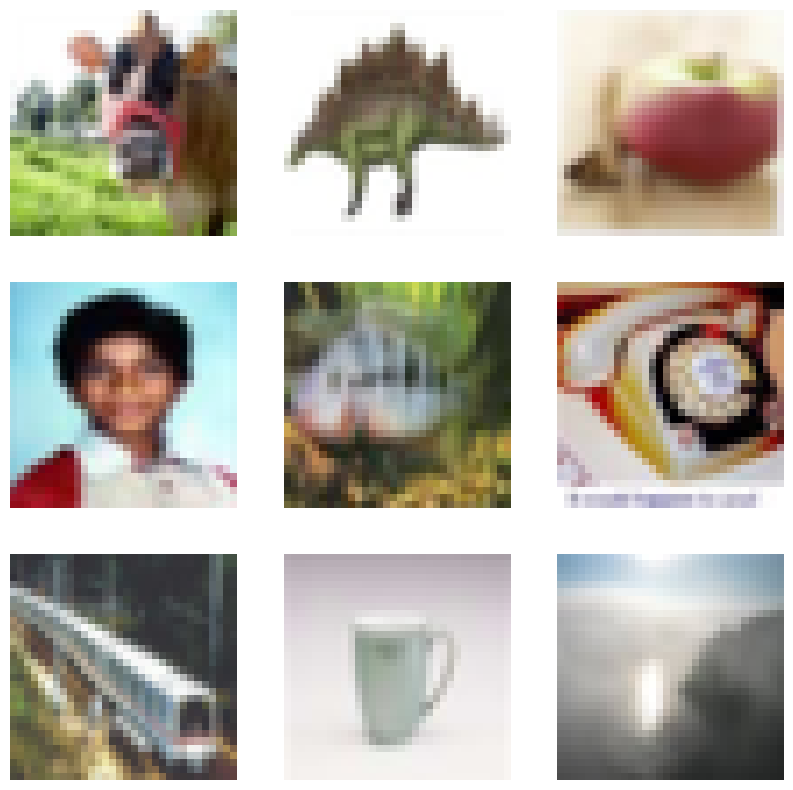

In [5]:
#Visualize Dataset
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

##Part 1: Custom CNN Model

In [6]:
custom_model = Sequential()

# First Block
custom_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001),
        input_shape=(32,32,3)
    )
)

custom_model.add(BatchNormalization())
custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.25))

# Second Block
custom_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    )
)

custom_model.add(BatchNormalization())
custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.30))

# Third Block
custom_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    )
)

custom_model.add(BatchNormalization())
custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.40))

# Flatten
custom_model.add(Flatten())

# Dense Layer
custom_model.add(Dense(256, activation='relu'))
custom_model.add(Dropout(0.5))

# Output Layer
custom_model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Compile Custom CNN Model
custom_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
custom_model.summary()   # summary

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,388 (2.46 MB)

 Trainable params: 643,940 (2.46 MB)

 Non-trainable params: 448 (1.75 KB)

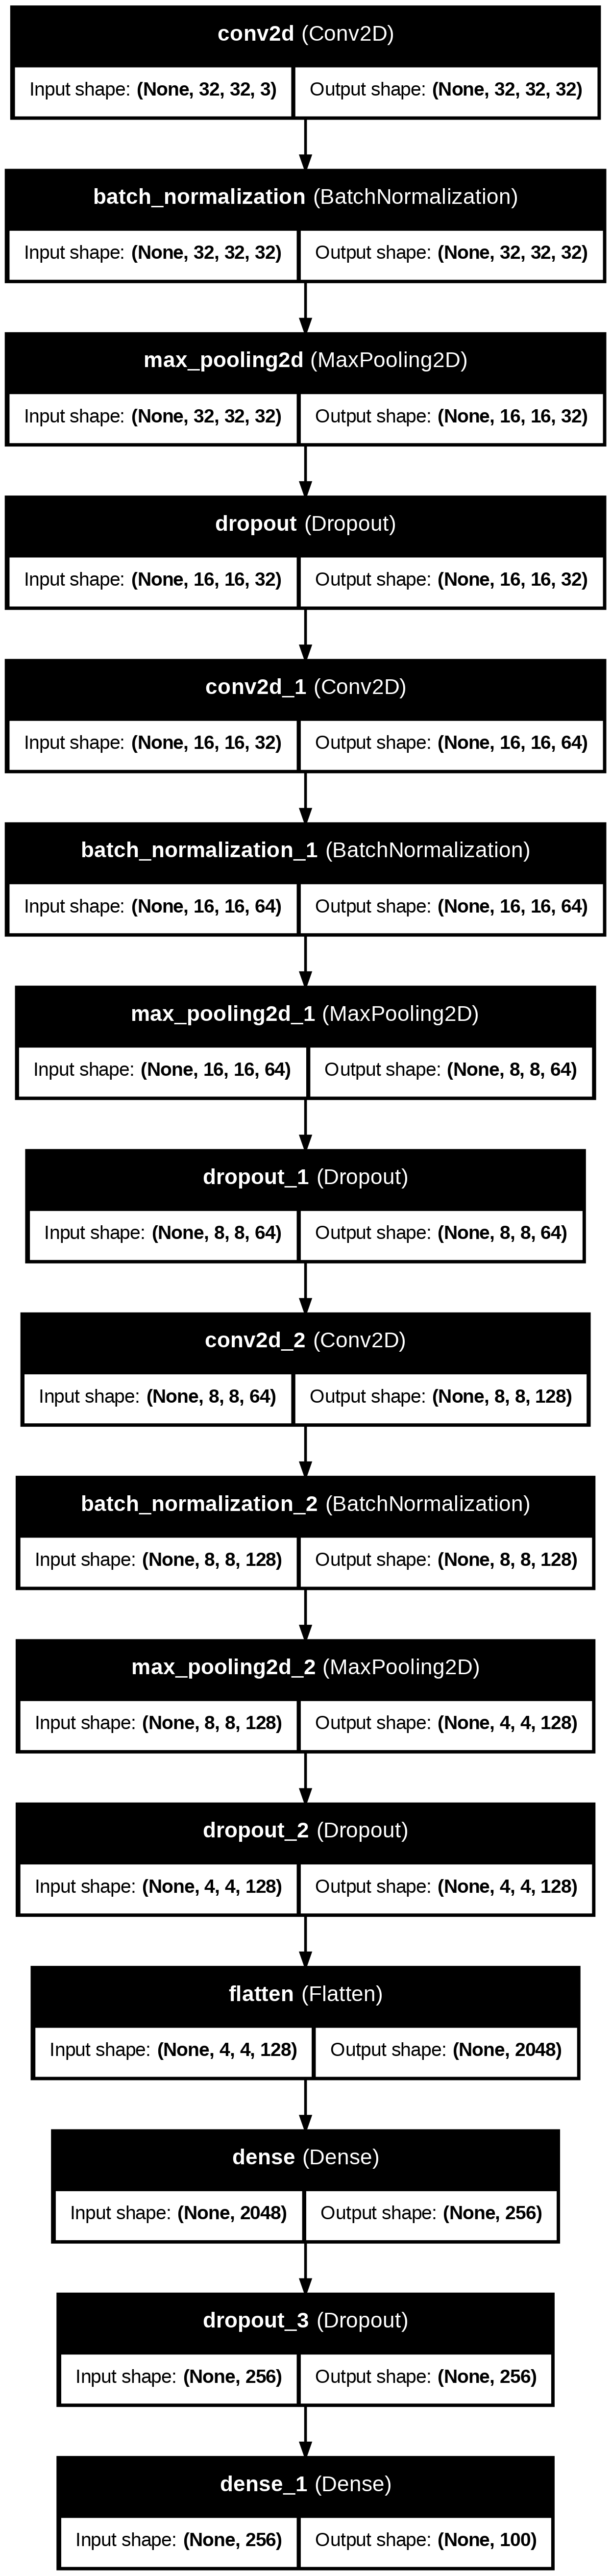

In [9]:
# plot model  CNN architecture
plot_model(
    custom_model,
    show_shapes=True,
    show_layer_names=True,
    to_file='custom_cnn_architecture.png'
)

In [10]:
#Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

check_point = ModelCheckpoint(
    'best_custom_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [11]:
# Train CNN model
history_custom = custom_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop, check_point]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0239 - loss: 5.0745
Epoch 1: val_accuracy improved from None to 0.09110, saving model to best_custom_model.h5



Epoch 1: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.0365 - loss: 4.8040 - val_accuracy: 0.0911 - val_loss: 4.3351
Epoch 2/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0615 - loss: 4.4225
Epoch 2: val_accuracy improved from 0.09110 to 0.11010, saving model to best_custom_model.h5



Epoch 2: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0674 - loss: 4.3490 - val_accuracy: 0.1101 - val_loss: 4.1159
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0878 - loss: 4.1536
Epoch 3: val_accuracy improved from 0.11010 to 0.17770, saving model to best_custom_model.h5



Epoch 3: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0945 - loss: 4.0910 - val_accuracy: 0.1777 - val_loss: 3.6608
Epoch 4/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1201 - loss: 3.9138
Epoch 4: val_accuracy improved from 0.17770 to 0.21250, saving model to best_custom_model.h5



Epoch 4: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1259 - loss: 3.8756 - val_accuracy: 0.2125 - val_loss: 3.4499
Epoch 5/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1492 - loss: 3.7185
Epoch 5: val_accuracy improved from 0.21250 to 0.24510, saving model to best_custom_model.h5


...


Epoch 21: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3907 - loss: 2.5184 - val_accuracy: 0.4469 - val_loss: 2.3551
Epoch 22/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4027 - loss: 2.4723
Epoch 22: val_accuracy improved from 0.44690 to 0.46170, saving model to best_custom_model.h5



Epoch 22: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3999 - loss: 2.4896 - val_accuracy: 0.4617 - val_loss: 2.2539
Epoch 23/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4038 - loss: 2.4580
Epoch 23: val_accuracy did not improve from 0.46170
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4014 - loss: 2.4719 - val_accuracy: 0.4540 - val_loss: 2.3039
Epoch 24/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4061 - loss: 2.4494
Epoch 24: val_accuracy did not improve from 0.46170
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4036 - loss: 2.4669 - val_accuracy: 0.4261 - val_loss: 2.4472
Epoch 25/30
774/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4112 - loss: 2.4248
Epoch 25: val_accuracy did not improve from 0.46170
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4088 - loss: 2.4367 - val_accuracy: 0.3922 - val_loss: 2.6726
Epoch 26/30
777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc


Epoch 26: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4144 - loss: 2.4177 - val_accuracy: 0.4816 - val_loss: 2.1705
Epoch 27/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4196 - loss: 2.3851
Epoch 27: val_accuracy did not improve from 0.48160
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4177 - loss: 2.4041 - val_accuracy: 0.4525 - val_loss: 2.3274
Epoch 28/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4261 - loss: 2.3648
Epoch 28: val_accuracy improved from 0.48160 to 0.48260, saving model to best_custom_model.h5



Epoch 28: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4216 - loss: 2.3902 - val_accuracy: 0.4826 - val_loss: 2.1655
Epoch 29/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4279 - loss: 2.3576
Epoch 29: val_accuracy did not improve from 0.48260
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4228 - loss: 2.3791 - val_accuracy: 0.4825 - val_loss: 2.1555
Epoch 30/30
772/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4295 - loss: 2.3462
Epoch 30: val_accuracy improved from 0.48260 to 0.48560, saving model to best_custom_model.h5



Epoch 30: finished saving model to best_custom_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4264 - loss: 2.3655 - val_accuracy: 0.4856 - val_loss: 2.1439


In [12]:
# Evaluate CNN model
custom_loss, custom_accuracy = custom_model.evaluate(x_test, y_test)

print("Custom CNN Test Accuracy:", custom_accuracy)
print("Custom CNN Test Loss:", custom_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4856 - loss: 2.1439
Custom CNN Test Accuracy: 0.48559999465942383
Custom CNN Test Loss: 2.143949031829834


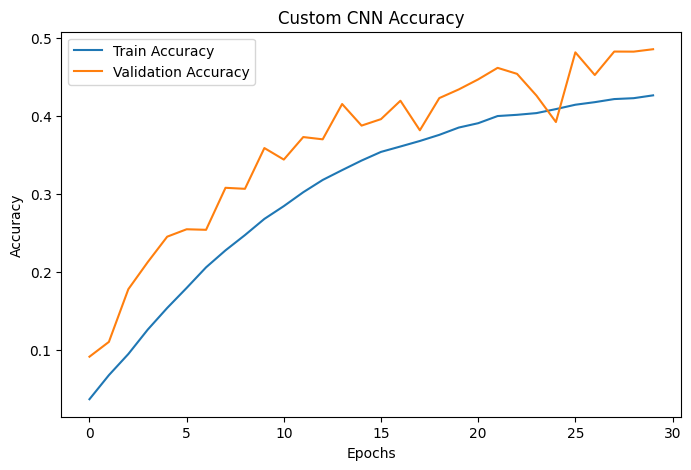

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_custom.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Custom CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

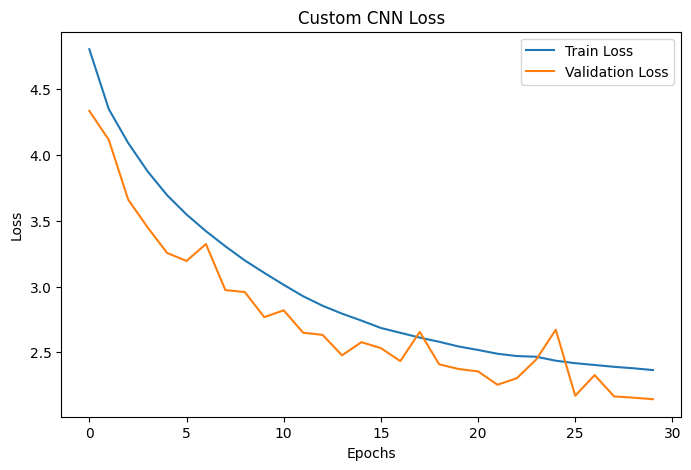

In [23]:
#LOSS curve
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_custom.history['val_loss'],
    label='Validation Loss'
)

plt.title('Custom CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Part 2: VGG-16 Model

In [13]:
#Load VGG16 Base Model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [14]:
#Build VGG16 Model
vgg_model = Sequential()

vgg_model.add(base_model)
vgg_model.add(GlobalAveragePooling2D())
vgg_model.add(Dense(256, activation='relu'))
vgg_model.add(Dropout(0.5))
vgg_model.add(Dense(100, activation='softmax'))

In [15]:
#Compile VGG16 Model
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,871,716 (56.73 MB)

 Trainable params: 157,028 (613.39 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

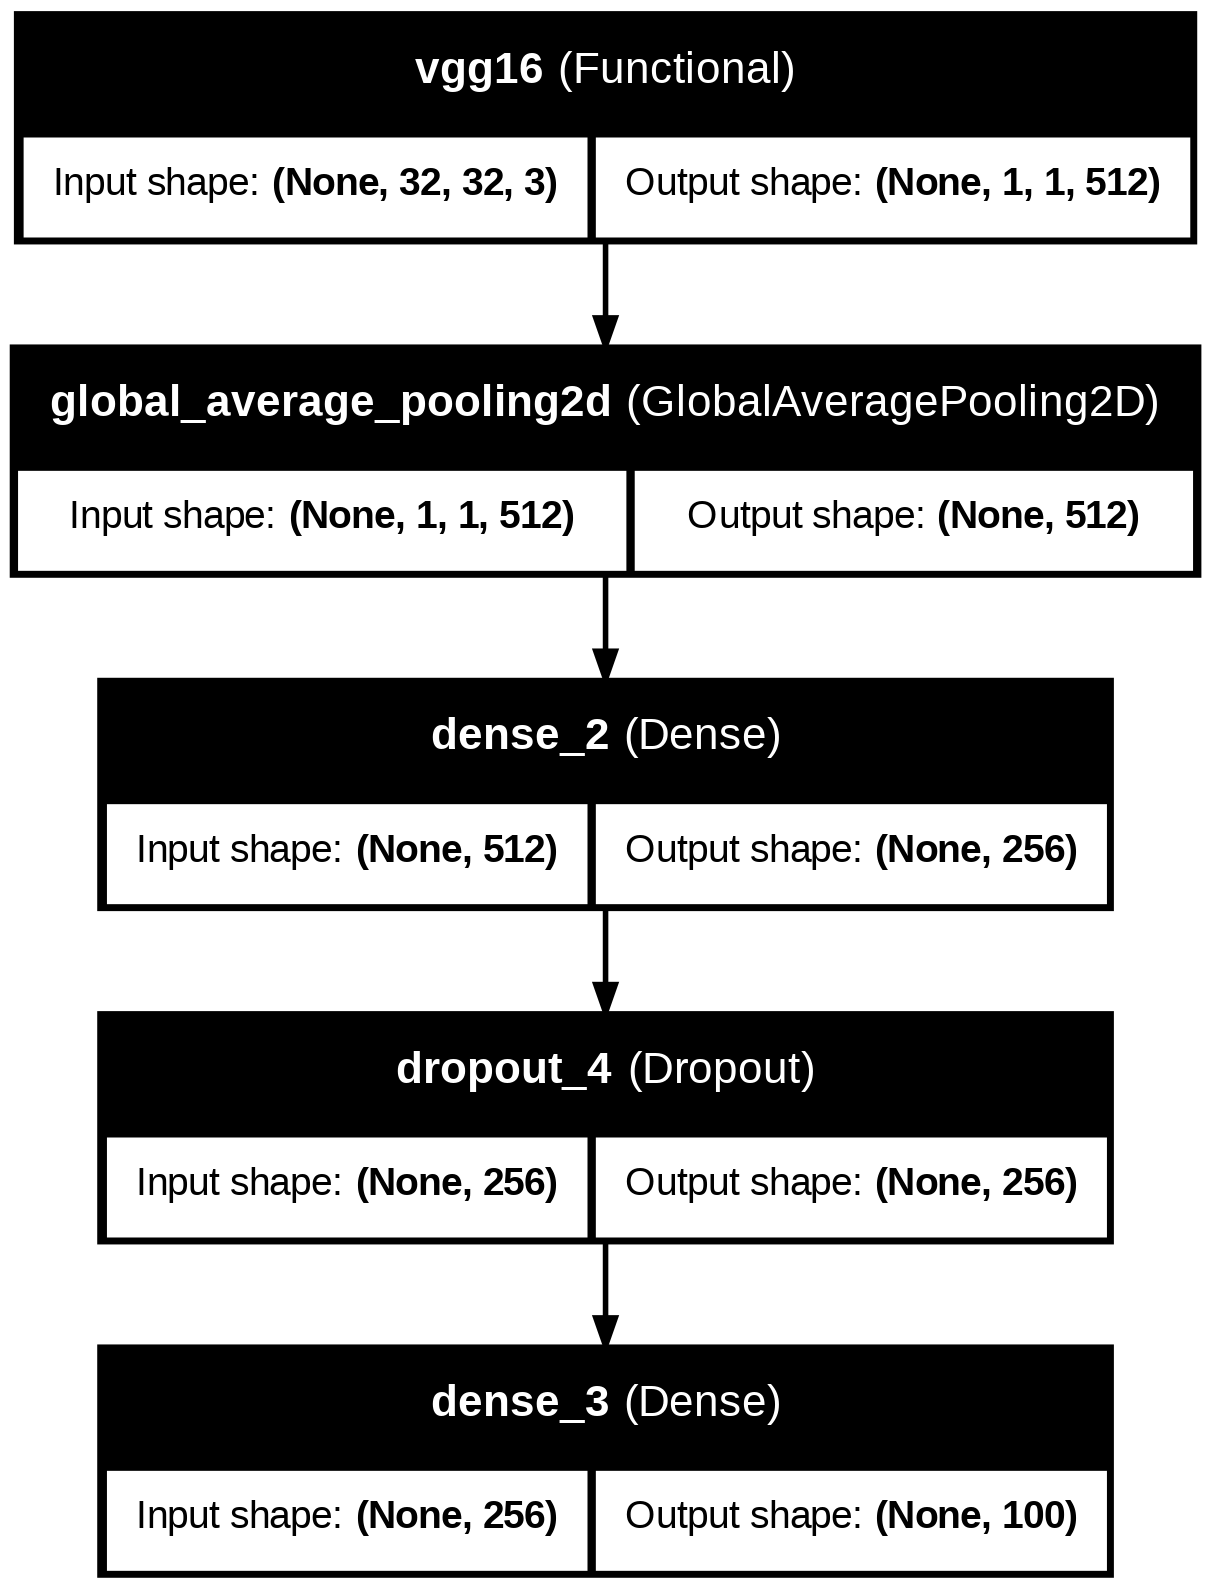

In [17]:
#Plot VGG16 Architecture
plot_model(
    vgg_model,
    show_shapes=True,
    show_layer_names=True,
    to_file='vgg16_architecture.png'
)

In [18]:
early_stop_vgg = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

check_point_vgg = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [19]:
#Train VGG16 model
history_vgg = vgg_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop_vgg, check_point_vgg]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1059 - loss: 3.9988
Epoch 1: val_accuracy improved from None to 0.26780, saving model to best_vgg16_model.h5



Epoch 1: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.1593 - loss: 3.6220 - val_accuracy: 0.2678 - val_loss: 3.0315
Epoch 2/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2377 - loss: 3.1364
Epoch 2: val_accuracy improved from 0.26780 to 0.29880, saving model to best_vgg16_model.h5



Epoch 2: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2443 - loss: 3.0932 - val_accuracy: 0.2988 - val_loss: 2.8448
Epoch 3/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2714 - loss: 2.9481
Epoch 3: val_accuracy improved from 0.29880 to 0.32140, saving model to best_vgg16_model.h5



Epoch 3: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2734 - loss: 2.9419 - val_accuracy: 0.3214 - val_loss: 2.7510
Epoch 4/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2823 - loss: 2.8676
Epoch 4: val_accuracy improved from 0.32140 to 0.32920, saving model to best_vgg16_model.h5



Epoch 4: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2859 - loss: 2.8588 - val_accuracy: 0.3292 - val_loss: 2.6888
Epoch 5/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2982 - loss: 2.7856
Epoch 5: val_accuracy improved from 0.32920 to 0.33310, saving model to best_vgg16_model.h5


...


Epoch 21: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3752 - loss: 2.3976 - val_accuracy: 0.3651 - val_loss: 2.5113
Epoch 22/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3869 - loss: 2.3656
Epoch 22: val_accuracy improved from 0.36510 to 0.36530, saving model to best_vgg16_model.h5



Epoch 22: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3812 - loss: 2.3829 - val_accuracy: 0.3653 - val_loss: 2.5191
Epoch 23/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3846 - loss: 2.3509
Epoch 23: val_accuracy improved from 0.36530 to 0.36570, saving model to best_vgg16_model.h5



Epoch 23: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3815 - loss: 2.3693 - val_accuracy: 0.3657 - val_loss: 2.5138
Epoch 24/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3865 - loss: 2.3379
Epoch 24: val_accuracy did not improve from 0.36570
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3831 - loss: 2.3590 - val_accuracy: 0.3650 - val_loss: 2.5226
Epoch 25/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3886 - loss: 2.3295
Epoch 25: val_accuracy improved from 0.36570 to 0.36830, saving model to best_vgg16_model.h5



Epoch 25: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3858 - loss: 2.3453 - val_accuracy: 0.3683 - val_loss: 2.5204
Epoch 26/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3924 - loss: 2.3146
Epoch 26: val_accuracy did not improve from 0.36830
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3866 - loss: 2.3358 - val_accuracy: 0.3660 - val_loss: 2.5211
Epoch 27/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3935 - loss: 2.3134
Epoch 27: val_accuracy did not improve from 0.36830
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3909 - loss: 2.3276 - val_accuracy: 0.3671 - val_loss: 2.5212
Epoch 28/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3998 - loss: 2.2874
Epoch 28: val_accuracy did not improve from 0.36830
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3936 - loss: 2.3113 - val_accuracy: 0.3659 - val_loss: 2.5144
Epoch 29/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms


Epoch 29: finished saving model to best_vgg16_model.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3973 - loss: 2.2974 - val_accuracy: 0.3700 - val_loss: 2.5287
Epoch 30/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3995 - loss: 2.2705
Epoch 30: val_accuracy did not improve from 0.37000
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3954 - loss: 2.2939 - val_accuracy: 0.3663 - val_loss: 2.5239


In [20]:
#Evaluate
vgg_loss, vgg_accuracy = vgg_model.evaluate(x_test, y_test)

print("VGG16 Test Accuracy:", vgg_accuracy)
print("VGG16 Test Loss:", vgg_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3700 - loss: 2.5287
VGG16 Test Accuracy: 0.3700000047683716
VGG16 Test Loss: 2.5287106037139893


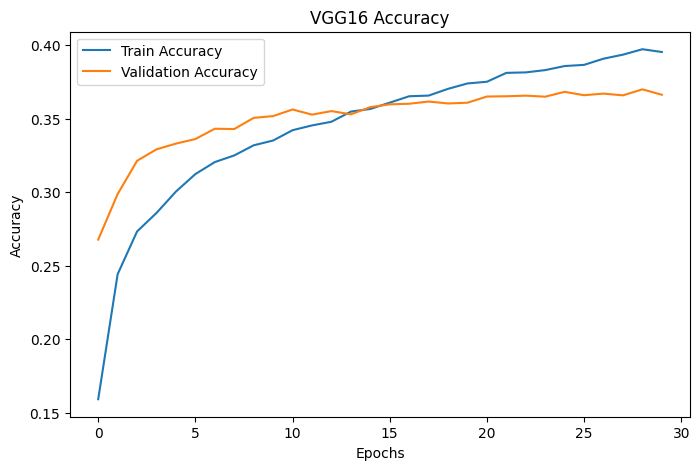

In [24]:
#Accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('VGG16 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

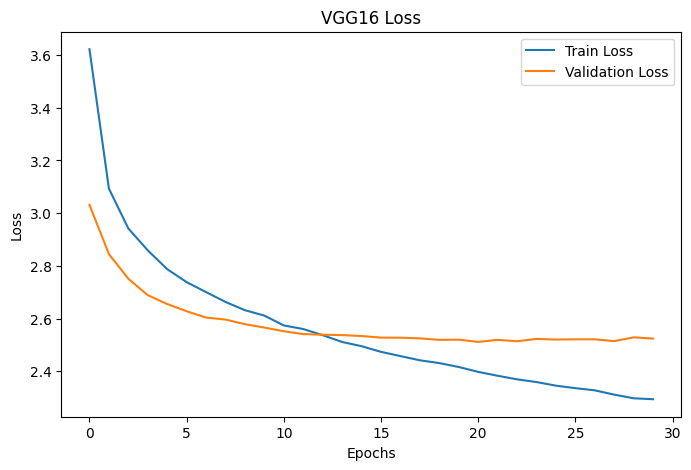

In [25]:
#Plot Loss Curves
plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_vgg.history['val_loss'],
    label='Validation Loss'
)

plt.title('VGG16 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Accuracy Comparison

In [26]:
#Accuracy Comparison Table
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16'],
    'Test Accuracy': [custom_accuracy, vgg_accuracy],
    'Test Loss': [custom_loss, vgg_loss]
})

comparison

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.4856,2.143949
1,VGG16,0.3700,2.528711


##Classification Report

In [27]:
# Predictions
predictions = custom_model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print(classification_report(true_classes, predicted_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.83      0.69      0.75       100
           1       0.64      0.62      0.63       100
           2       0.44      0.33      0.38       100
           3       0.27      0.27      0.27       100
           4       0.28      0.22      0.25       100
           5       0.47      0.45      0.46       100
           6       0.47      0.54      0.50       100
           7       0.52      0.52      0.52       100
           8       0.62      0.68      0.65       100
           9       0.69      0.64      0.66       100
          10       0.46      0.46      0.46       100
          11       0.62      0.21      0.31       100
          12       0.49      0.55      0.52       100
          13       0.55      0.29      0.38       100
          14       0.50      0.32      0.39       100
          15       0.42      0.35      0.38       100
          16       0.49      0.56      0

In [33]:
from sklearn.metrics import classification_report
import pandas as pd

# Predictions
predictions = custom_model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Classification report as dictionary
report = classification_report(
    true_classes,
    predicted_classes,
    output_dict=True
)

# Convert to dataframe
report_df = pd.DataFrame(report).transpose()

# Show only important columns
report_df = report_df[['precision', 'recall', 'f1-score', 'support']]

report_df.head(10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,precision,recall,f1-score,support
0,0.831325,0.69,0.754098,100.0
1,0.639175,0.62,0.629442,100.0
2,0.440000,0.33,0.377143,100.0
3,0.270000,0.27,0.270000,100.0
4,0.278481,0.22,0.245810,100.0
5,0.473684,0.45,0.461538,100.0
6,0.473684,0.54,0.504673,100.0
7,0.520000,0.52,0.520000,100.0
8,0.618182,0.68,0.647619,100.0
9,0.688172,0.64,0.663212,100.0


###  Best Model

In [30]:
# Find best model
best_model = comparison_df.loc[
    comparison_df['Test Accuracy (%)'].idxmax()
]

print("\nBest Performing Model:")
print(best_model)


Best Performing Model:
Model                Custom CNN
Test Accuracy (%)     48.559999
Test Loss              2.143949
Name: 0, dtype: object


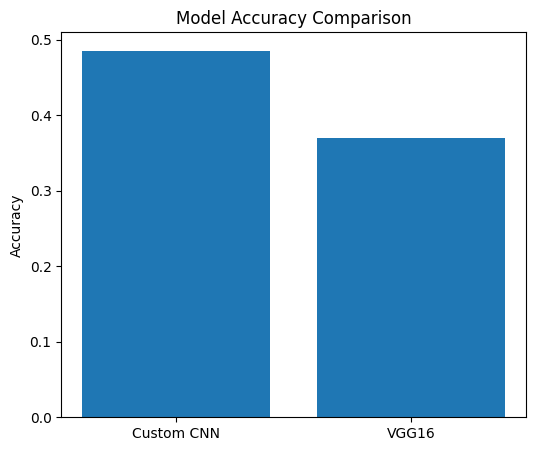

In [31]:
#Visual Comparison
models = ['Custom CNN', 'VGG16']
accuracies = [custom_accuracy, vgg_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

##Conclusion

###The custom CNN model was built from scratch using convolutional layers, dropout, batch normalization, and regularization techniques.

###VGG16 achieved better feature extraction because it is a pretrained deep architecture.

*Both models were evaluated using test accuracy and loss.

*   EarlyStopping prevented overfitting.
*  ModelCheckpoint saved the best model during training.
###Overall, the Custom CNN architecture proved to be the best-performing model for this case study and demonstrated that a properly designed CNN from scratch can achieve strong image classification performance on complex datasets like CIFAR-100

